In [151]:
import pandas as pd
val_df = pd.read_csv("/kaggle/input/diabetic-retinopathy-224x224-2019-data/train.csv")
print(val_df['diagnosis'].value_counts(normalize=True) * 100)

diagnosis
0    49.290005
2    27.280175
1    10.103768
4     8.055707
3     5.270344
Name: proportion, dtype: float64


In [152]:
import os

base_dir = "/kaggle/input/diabetic-retinopathy-224x224-2019-data/colored_images"


In [153]:
import pandas as pd

# Load the APTOS 2019 224x224 dataset CSV
df = pd.read_csv("/kaggle/input/diabetic-retinopathy-224x224-2019-data/train.csv")

# Append '.png' to image_id if needed (file extension might be '.png' or '.jpg')
df['image_id'] = df['id_code'].astype(str) + '.png'

# Rename diagnosis to label (optional, for convenience)
df['label'] = df['diagnosis']

# Final columns check
print("✅ Loaded CSV - Columns:", df.columns)
print("🔢 Label distribution:\n", df['label'].value_counts())

✅ Loaded CSV - Columns: Index(['id_code', 'diagnosis', 'image_id', 'label'], dtype='object')
🔢 Label distribution:
 label
0    1805
2     999
1     370
4     295
3     193
Name: count, dtype: int64


In [154]:
from torch.utils.data import Dataset
import os
from PIL import Image

class DRDataset(Dataset):
    def __init__(self, df, image_dir, transform=None):
        self.df = df.reset_index(drop=True)
        self.image_dir = image_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        label = int(row['diagnosis'])
        image_id = row['image_id']  # Already has '.png'

        img_path = os.path.join(self.image_dir, image_id)
        if not os.path.exists(img_path):
            raise FileNotFoundError(f"Image not found: {img_path}")

        image = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)

        return image, label

In [155]:
print(df.columns)

Index(['id_code', 'diagnosis', 'image_id', 'label'], dtype='object')


In [156]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import classification_report, confusion_matrix, cohen_kappa_score
from PIL import Image
import pandas as pd
import numpy as np
from tqdm import tqdm
import timm
import matplotlib.pyplot as plt
import seaborn as sns

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Constants
NUM_CLASSES = 5
IMG_SIZE = 224
BATCH_SIZE = 16
EPOCHS = 10

class DRDataset(Dataset):
    def __init__(self, df, image_dir, transform=None):
        self.df = df.reset_index(drop=True)
        self.image_dir = image_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        label = int(row['diagnosis'])
        id_code = row['id_code']  # <-- FIXED here
        image_name = id_code + '.png'  # <-- also changed
    
        folder_map = {
            0: 'No_DR',
            1: 'Mild',
            2: 'Moderate',
            3: 'Severe',
            4: 'Proliferate_DR'
    }
        folder_name = folder_map[label]
        img_path = os.path.join(self.image_dir, folder_name, image_name)

        if not os.path.exists(img_path):
            raise FileNotFoundError(f"Image not found at: {img_path}")

        image = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)

        return image, label

In [157]:
import os
import pandas as pd

image_dir = '/kaggle/input/diabetic-retinopathy-224x224-2019-data/colored_images'
df = pd.read_csv('/kaggle/input/diabetic-retinopathy-224x224-2019-data/train.csv')

df['image_id'] = df['id_code'] + '.png'

# Build list of available images from all 5 subfolders
available_images = set()
for root, dirs, files in os.walk(image_dir):
    for file in files:
        if file.endswith('.png'):
            available_images.add(file)

# Filter
df = df[df['image_id'].isin(available_images)].reset_index(drop=True)
print("✅ Final filtered df shape:", df.shape)

✅ Final filtered df shape: (3662, 3)


In [158]:
print("👉 df columns:", df.columns.tolist())

👉 df columns: ['id_code', 'diagnosis', 'image_id']


In [159]:
df = df.loc[:, ~df.columns.duplicated()]

In [160]:
# Correct dataset path for APTOS 2019 (224x224)
image_dir = '/kaggle/input/diabetic-retinopathy-224x224-2019-data/colored_images'

# Load CSV
df = pd.read_csv('/kaggle/input/diabetic-retinopathy-224x224-2019-data/train.csv')
df['image_id'] = df['id_code'].astype(str) + '.png'  # If needed

# List available image files
available_images = []
for root, dirs, files in os.walk(image_dir):
    for file in files:
        if file.endswith('.png'):
            available_images.append(file)

# Filter only rows where image file exists
df = df[df['image_id'].isin(available_images)].reset_index(drop=True)
print("✅ Final filtered df shape:", df.shape)

✅ Final filtered df shape: (3662, 3)


In [161]:
import os
import pandas as pd

IMG_DIR = '/kaggle/input/diabetic-retinopathy-224x224-2019-data/colored_images'

# List all available .png images in the directory
available_images = set(os.listdir(IMG_DIR))

In [162]:
import os
import pandas as pd

# Correct dataset path
image_dir = '/kaggle/input/diabetic-retinopathy-224x224-2019-data/colored_images'

# Load CSV
df = pd.read_csv('/kaggle/input/diabetic-retinopathy-224x224-2019-data/train.csv')

# ✅ If not already added, append '.png'
df['image_id'] = df['id_code'].astype(str)
if not df['image_id'].iloc[0].endswith('.png'):
    df['image_id'] = df['image_id'] + '.png'

# ✅ List available .png image files
available_images = set()
for root, _, files in os.walk(image_dir):
    for file in files:
        if file.endswith('.png'):
            available_images.add(file)

# ✅ Keep only rows for which image file actually exists
df = df[df['image_id'].isin(available_images)].reset_index(drop=True)
print("✅ Final filtered df shape:", df.shape)

✅ Final filtered df shape: (3662, 3)


In [163]:
print(df['image_id'].head(10).tolist())

['000c1434d8d7.png', '001639a390f0.png', '0024cdab0c1e.png', '002c21358ce6.png', '005b95c28852.png', '0083ee8054ee.png', '0097f532ac9f.png', '00a8624548a9.png', '00b74780d31d.png', '00cb6555d108.png']


In [164]:
from torchvision import transforms

IMG_SIZE = 224  # Use 224x224 since the dataset is already resized

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
])

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
])

In [165]:
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader

# ✅ Split into train/val (stratified by diagnosis)
train_df, val_df = train_test_split(
    df, test_size=0.2, stratify=df['diagnosis'], random_state=42
)

# ✅ Image directory (APTOS 2019 classwise)
image_dir = '/kaggle/input/diabetic-retinopathy-224x224-2019-data/colored_images'

# ✅ Create datasets
train_dataset = DRDataset(train_df, image_dir=image_dir, transform=train_transform)
val_dataset   = DRDataset(val_df, image_dir=image_dir, transform=val_transform)

# ✅ Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
val_loader   = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2)

In [166]:
print(df.columns.tolist())
print(df.head())

['id_code', 'diagnosis', 'image_id']
        id_code  diagnosis          image_id
0  000c1434d8d7          2  000c1434d8d7.png
1  001639a390f0          4  001639a390f0.png
2  0024cdab0c1e          1  0024cdab0c1e.png
3  002c21358ce6          0  002c21358ce6.png
4  005b95c28852          0  005b95c28852.png


In [167]:
from torch.utils.data import Dataset
import os
from PIL import Image

class DRDataset(Dataset):
    def __init__(self, df, image_dir, transform=None):
        self.df = df.reset_index(drop=True)
        self.image_dir = image_dir
        self.transform = transform

        # ✅ Define the label-to-folder mapping
        self.label_map = {
            0: 'No_DR',
            1: 'Mild',
            2: 'Moderate',
            3: 'Severe',
            4: 'Proliferate_DR'
        }

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        label = int(row['diagnosis'])          # Use the original diagnosis
        image_id = row['image_id']             # Includes ".png"

        # ✅ Correctly construct path using label-based subfolder
        folder = self.label_map[label]
        img_path = os.path.join(self.image_dir, folder, image_id)

        if not os.path.exists(img_path):
            raise FileNotFoundError(f"Image not found: {img_path}")

        image = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)

        return image, label

In [168]:
import torch

# Automatically use GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✅ Using device: {device}")

✅ Using device: cuda


In [169]:
# --- Cell 4: Hyperparameters, Model Definitions, Loss, Optimizers, and Schedulers ---

import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.cuda.amp import GradScaler
from torch.optim.lr_scheduler import CosineAnnealingWarmRestarts
import timm

# --- Training Hyperparameters ---
LEARNING_RATE = 3e-4
WEIGHT_DECAY = 1e-4
EPOCHS = 25
EARLY_STOPPING_PATIENCE = 8
MIN_DELTA_KAPPA = 1e-4
NUM_CLASSES = 5
FOCAL_LOSS_GAMMA = 2.0

# --- Focal Loss Class ---
class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=FOCAL_LOSS_GAMMA, reduction='mean'):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, reduction='none')
        pt = torch.exp(-ce_loss)

        if self.alpha is not None:
            if self.alpha.dim() == 1:
                alpha_t = self.alpha.gather(0, targets)
                loss = alpha_t * (1 - pt) ** self.gamma * ce_loss
            else:
                raise ValueError("Alpha must be 1D for multi-class FocalLoss.")
        else:
            loss = (1 - pt) ** self.gamma * ce_loss

        return loss.mean() if self.reduction == 'mean' else loss.sum()

# --- CoAtNet Model Definition ---
class CoAtNetModel(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES):
        super().__init__()
        self.model = timm.create_model('coatnet_bn_0_rw_224', pretrained=True, num_classes=num_classes)

    def forward(self, x):
        return self.model(x)

# --- Instantiate the model and move to device ---
coatnet_model = CoAtNetModel(num_classes=NUM_CLASSES).to(device)

# --- Class Weights for Focal Loss ---
class_counts = train_df['diagnosis'].value_counts().sort_index()
alpha_loss = 1.0 / class_counts.values
alpha_loss = torch.tensor(alpha_loss, dtype=torch.float).to(device)
alpha_loss = alpha_loss / alpha_loss.sum()  # Normalize

# --- Loss Function ---
criterion = FocalLoss(alpha=alpha_loss, gamma=FOCAL_LOSS_GAMMA, reduction='mean').to(device)

# --- Optimizer ---
coatnet_optimizer = optim.AdamW(coatnet_model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

# --- Scheduler ---
coatnet_scheduler = CosineAnnealingWarmRestarts(
    coatnet_optimizer, 
    T_0=10, T_mult=2, eta_min=1e-6
)

print("✅ CoAtNet, FocalLoss, Optimizer, Scheduler initialized.")


✅ CoAtNet, FocalLoss, Optimizer, Scheduler initialized.


In [170]:
from sklearn.metrics import cohen_kappa_score
from tqdm import tqdm
import numpy as np
import torch

def train_model(model_name, model, train_loader, val_loader, criterion, optimizer, scheduler, device, epochs, patience, min_delta_kappa):
    best_val_kappa = -1.0
    best_val_acc = -1.0
    wait = 0
    model_path = f'best_{model_name}_aptos.pth'
    scaler = GradScaler()

    history = {
        'train_loss': [], 'val_loss': [],
        'train_acc': [],  'val_acc': [],
        'train_kappa': [], 'val_kappa': [],
        'lr': []
    }

    print(f"\n--- Starting training for {model_name} ---")
    for epoch in range(epochs):
        model.train()
        train_loss = 0.0
        all_train_preds, all_train_labels = [], []

        for batch_idx, (images, labels) in tqdm(enumerate(train_loader), total=len(train_loader), desc=f"[{model_name} Epoch {epoch+1}/{epochs}] Training"):
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()

            with torch.amp.autocast(device_type=device.type):
                outputs = model(images)
                loss = criterion(outputs, labels)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            train_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            all_train_preds.extend(preds.cpu().numpy())
            all_train_labels.extend(labels.cpu().numpy())

            scheduler.step(epoch + (batch_idx + 1) / len(train_loader))

        avg_train_loss = train_loss / len(train_loader)
        train_acc = np.mean(np.array(all_train_preds) == np.array(all_train_labels))
        train_kappa = cohen_kappa_score(all_train_labels, all_train_preds, weights='quadratic')

        # --- Validation ---
        model.eval()
        val_loss = 0.0
        all_val_preds, all_val_labels = [], []

        with torch.no_grad():
            for images, labels in tqdm(val_loader, desc=f"[{model_name} Epoch {epoch+1}/{epochs}] Validation"):
                images, labels = images.to(device), labels.to(device)
                with torch.amp.autocast(device_type=device.type):
                    outputs = model(images)
                    loss = criterion(outputs, labels)

                val_loss += loss.item()
                _, preds = torch.max(outputs, 1)
                all_val_preds.extend(preds.cpu().numpy())
                all_val_labels.extend(labels.cpu().numpy())

        avg_val_loss = val_loss / len(val_loader)
        val_acc = np.mean(np.array(all_val_preds) == np.array(all_val_labels))
        val_kappa = cohen_kappa_score(all_val_labels, all_val_preds, weights='quadratic')
        current_lr = optimizer.param_groups[0]['lr']

        print(f"[{model_name} Epoch {epoch+1}]: Train Loss={avg_train_loss:.4f}, Acc={train_acc:.4f}, Kappa={train_kappa:.4f} | Val Loss={avg_val_loss:.4f}, Acc={val_acc:.4f}, Kappa={val_kappa:.4f} | LR={current_lr:.6f}")

        # Save metrics
        history['train_loss'].append(avg_train_loss)
        history['val_loss'].append(avg_val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)
        history['train_kappa'].append(train_kappa)
        history['val_kappa'].append(val_kappa)
        history['lr'].append(current_lr)

        # ✅ Save best model if improved
        if (val_kappa > best_val_kappa + min_delta_kappa) or (val_acc > best_val_acc):
            best_val_kappa = max(best_val_kappa, val_kappa)
            best_val_acc = max(best_val_acc, val_acc)
            wait = 0
            torch.save(model.state_dict(), model_path)
            print(f"✅ Best {model_name} model saved. Val Kappa: {val_kappa:.4f}, Val Acc: {val_acc:.4f}")
        else:
            wait += 1
            if wait >= patience:
                print(f"⛔ Early stopping: {wait} epochs without improvement.")
                break

    print(f"\n--- Training complete for {model_name} ---")
    print(f"🏆 Best Val Kappa: {best_val_kappa:.4f} | Best Val Acc: {best_val_acc:.4f}")
    return model_path, best_val_kappa, best_val_acc, history

In [171]:
import matplotlib.pyplot as plt

def plot_training_curves(history, model_name="Model", save_path=None):
    epochs = range(1, len(history['train_loss']) + 1)
    plt.figure(figsize=(18, 5))

    # 📉 Loss
    plt.subplot(1, 3, 1)
    plt.plot(epochs, history['train_loss'], label='Train Loss', marker='o')
    plt.plot(epochs, history['val_loss'], label='Val Loss', marker='o')
    plt.title(f'{model_name} Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.5)

    # 📈 Accuracy
    plt.subplot(1, 3, 2)
    plt.plot(epochs, history['train_acc'], label='Train Acc', marker='o')
    plt.plot(epochs, history['val_acc'], label='Val Acc', marker='o')
    plt.title(f'{model_name} Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.5)

    # 🧠 Kappa
    plt.subplot(1, 3, 3)
    plt.plot(epochs, history['train_kappa'], label='Train Kappa', marker='o')
    plt.plot(epochs, history['val_kappa'], label='Val Kappa', marker='o')
    plt.title(f'{model_name} Quadratic Kappa')
    plt.xlabel('Epoch')
    plt.ylabel('Kappa')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.5)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path)
    plt.show()

In [172]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import torch

def plot_confusion_matrix(model, dataloader, device, class_names, model_name="Model"):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    cm = confusion_matrix(all_labels, all_preds, labels=range(len(class_names)))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

    fig, ax = plt.subplots(figsize=(8, 6))
    disp.plot(cmap='Blues', ax=ax, xticks_rotation=45, values_format='d')
    ax.set_title(f'{model_name} Confusion Matrix', fontsize=14)
    plt.tight_layout()
    plt.show()


--- Training CoAtNet ---

--- Starting training for CoAtNet ---


/tmp/ipykernel_36/3092903379.py:11: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()
[CoAtNet Epoch 1/25] Validation: 100%|██████████| 23/23 [00:02<00:00, 10.34it/s]


[CoAtNet Epoch 1]: Train Loss=0.0675, Acc=0.6497, Kappa=0.7259 | Val Loss=0.0608, Acc=0.6835, Kappa=0.7796 | LR=0.000293
✅ Best CoAtNet model saved. Val Kappa: 0.7796, Val Acc: 0.6835


[CoAtNet Epoch 2/25] Validation: 100%|██████████| 23/23 [00:02<00:00, 10.94it/s]


[CoAtNet Epoch 2]: Train Loss=0.0442, Acc=0.7491, Kappa=0.8347 | Val Loss=0.0505, Acc=0.7080, Kappa=0.8096 | LR=0.000271
✅ Best CoAtNet model saved. Val Kappa: 0.8096, Val Acc: 0.7080


...

[CoAtNet Epoch 23]: Train Loss=0.0020, Acc=0.9860, Kappa=0.9934 | Val Loss=0.0750, Acc=0.8281, Kappa=0.8974 | LR=0.000083
✅ Best CoAtNet model saved. Val Kappa: 0.8974, Val Acc: 0.8281


[CoAtNet Epoch 24/25] Validation: 100%|██████████| 23/23 [00:02<00:00, 11.00it/s]


[CoAtNet Epoch 24]: Train Loss=0.0015, Acc=0.9887, Kappa=0.9946 | Val Loss=0.0785, Acc=0.8349, Kappa=0.8921 | LR=0.000063


[CoAtNet Epoch 25/25] Validation: 100%|██████████| 23/23 [00:02<00:00, 10.84it/s]


[CoAtNet Epoch 25]: Train Loss=0.0013, Acc=0.9887, Kappa=0.9942 | Val Loss=0.0771, Acc=0.8322, Kappa=0.8878 | LR=0.000045

--- Training complete for CoAtNet ---
🏆 Best Val Kappa: 0.8974 | Best Val Acc: 0.8472

--- Best CoAtNet Results ---
Best Val Kappa: 0.8974
Best Val Accuracy: 0.8472


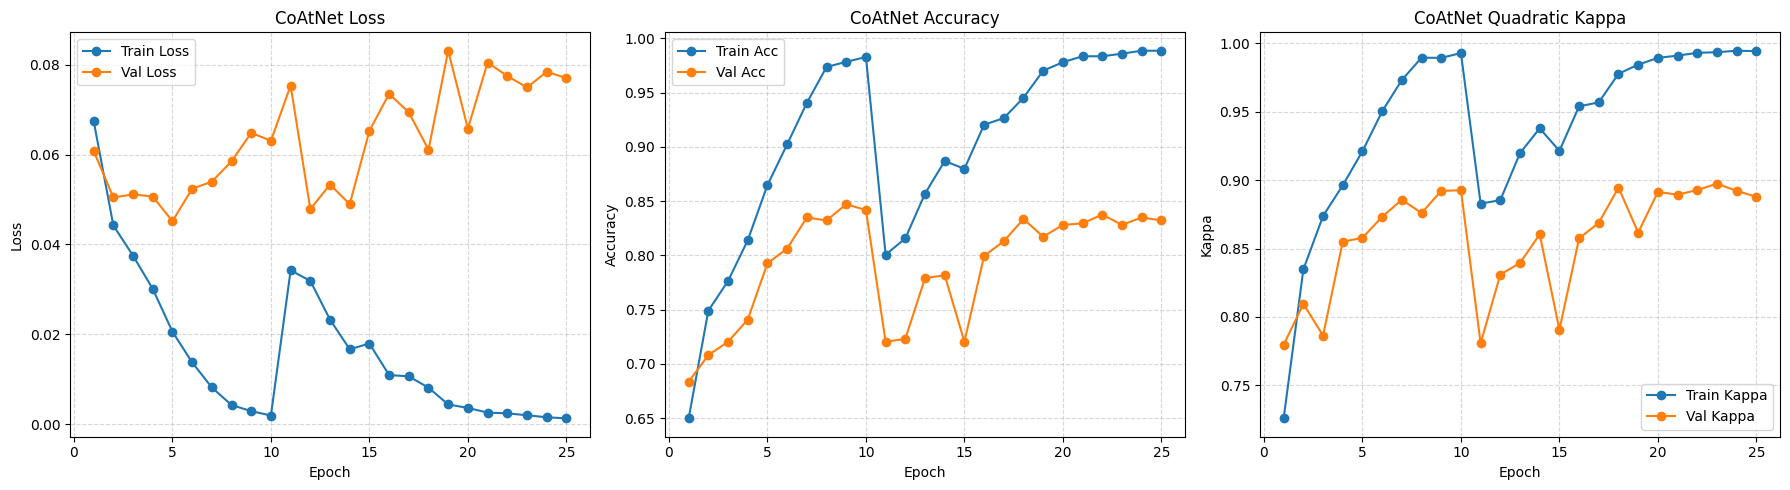

In [173]:
 # Cell 6
#--- Train Only CoAtNet ---

print("\n--- Training CoAtNet ---")
coatnet_best_path, coatnet_best_kappa, coatnet_best_acc, coatnet_history = train_model(
     "CoAtNet", coatnet_model, train_loader, val_loader, criterion,
     coatnet_optimizer, coatnet_scheduler, device, EPOCHS,
     EARLY_STOPPING_PATIENCE, MIN_DELTA_KAPPA
)
# --- Print Final Best Results ---
print("\n--- Best CoAtNet Results ---")
print(f"Best Val Kappa: {coatnet_best_kappa:.4f}")
print(f"Best Val Accuracy: {coatnet_best_acc:.4f}")

# --- Optional: Plot Curves ---
plot_training_curves(coatnet_history, model_name="CoAtNet")

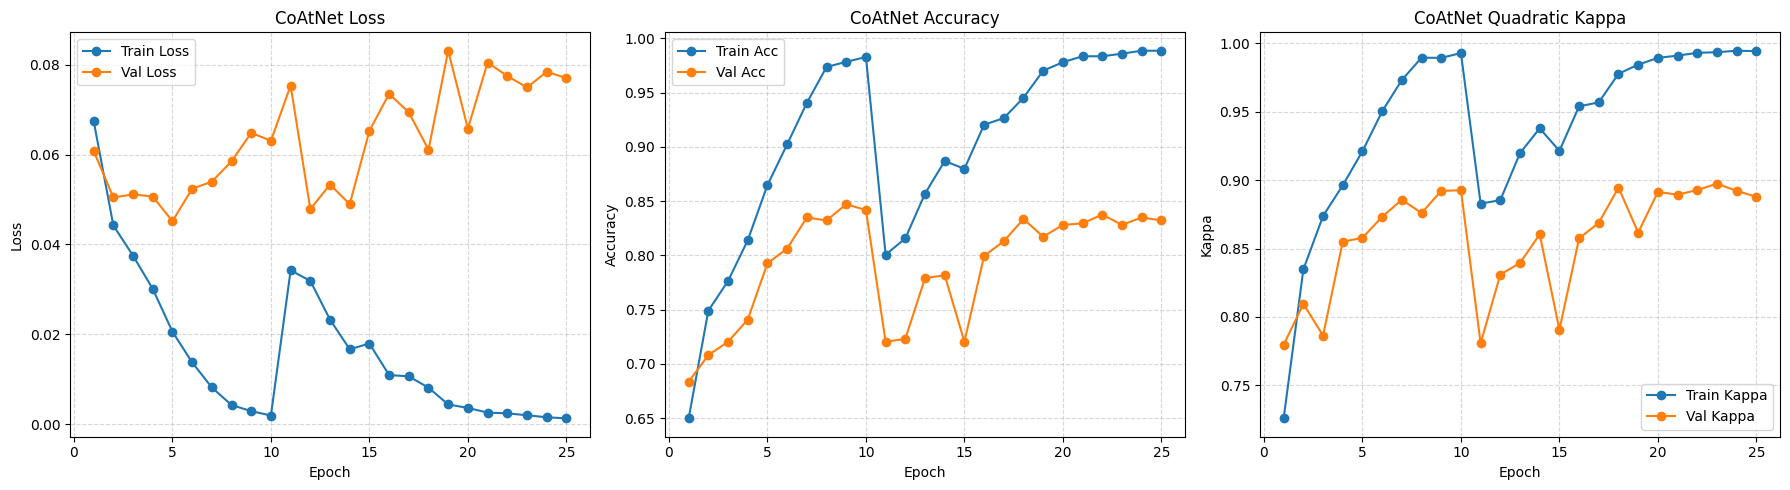

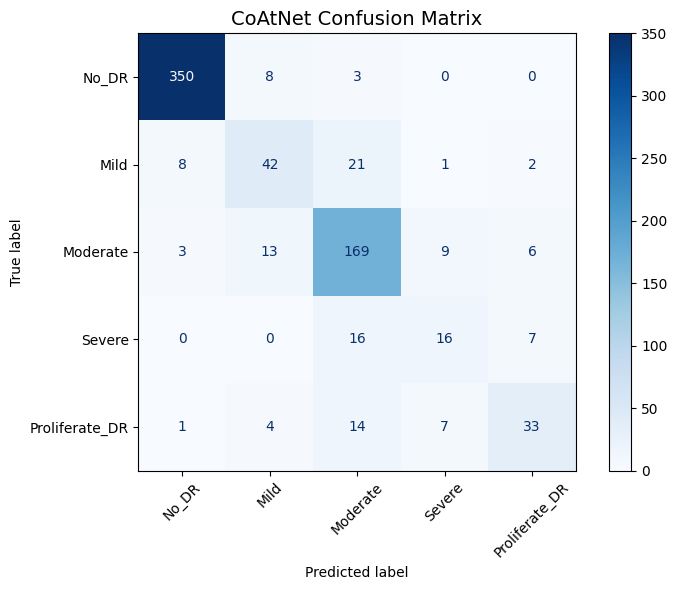

In [174]:
plot_training_curves(coatnet_history, model_name="CoAtNet")

class_names = ['No_DR', 'Mild', 'Moderate', 'Severe', 'Proliferate_DR']
plot_confusion_matrix(coatnet_model, val_loader, device, class_names, model_name="CoAtNet")

In [175]:
##################################################
################################################## 
######### 5 Fold Cross Validation ################
##################################################
##################################################

In [183]:
#Cell 0
import os
import numpy as np
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import cohen_kappa_score
import timm
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.cuda.amp import GradScaler
from torch.optim.lr_scheduler import CosineAnnealingWarmRestarts
import matplotlib.pyplot as plt
from tqdm import tqdm

In [184]:
#Cell 1
from PIL import Image

class DRDataset(Dataset):
    def __init__(self, df, image_dir, transform=None):
        self.df = df.reset_index(drop=True)
        self.image_dir = image_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        label = int(row['diagnosis'])
        image_id = row['image_id']
        
        # Loop through all class folders to find image
        for folder in os.listdir(self.image_dir):
            img_path = os.path.join(self.image_dir, folder, image_id)
            if os.path.exists(img_path):
                break
        else:
            raise FileNotFoundError(f"Image not found in any class folder: {image_id}")
        
        image = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image, label

In [185]:
#Cell 3
FOCAL_LOSS_GAMMA = 2.0

class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=FOCAL_LOSS_GAMMA, reduction='mean'):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, reduction='none')
        pt = torch.exp(-ce_loss)

        if self.alpha is not None:
            if self.alpha.dim() == 1:
                alpha_t = self.alpha.gather(0, targets)
                loss = alpha_t * (1 - pt) ** self.gamma * ce_loss
            else:
                raise ValueError("Alpha must be 1D for multi-class FocalLoss.")
        else:
            loss = (1 - pt) ** self.gamma * ce_loss

        return loss.mean() if self.reduction == 'mean' else loss.sum()

In [186]:
#Cell 4
class CoAtNetModel(nn.Module):
    def __init__(self, num_classes=5):
        super().__init__()
        self.model = timm.create_model('coatnet_bn_0_rw_224', pretrained=True, num_classes=num_classes)

    def forward(self, x):
        return self.model(x)

In [192]:
#Cell 5
def train_model(model_name, model, train_loader, val_loader, criterion, optimizer, scheduler, device, epochs, patience, min_delta_kappa):
    best_val_kappa = -1.0
    best_val_acc = -1.0
    wait = 0
    model_path = f'best_{model_name}.pth'
    scaler = GradScaler()

    history = {
        'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': [],
        'train_kappa': [], 'val_kappa': [], 'lr': []
    }

    for epoch in range(epochs):
        model.train()
        train_loss, all_train_preds, all_train_labels = 0.0, [], []

        for batch_idx, (images, labels) in tqdm(enumerate(train_loader), total=len(train_loader), desc=f"[{model_name} Epoch {epoch+1}/{epochs}] Training"):
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()

            with torch.amp.autocast(device_type=device.type):
                outputs = model(images)
                loss = criterion(outputs, labels)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            train_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            all_train_preds.extend(preds.cpu().numpy())
            all_train_labels.extend(labels.cpu().numpy())

            scheduler.step(epoch + (batch_idx + 1) / len(train_loader))

        avg_train_loss = train_loss / len(train_loader)
        train_kappa = cohen_kappa_score(all_train_labels, all_train_preds, weights='quadratic')
        train_acc = np.mean(np.array(all_train_preds) == np.array(all_train_labels))

        # Validation
        model.eval()
        val_loss, all_val_preds, all_val_labels = 0.0, [], []

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                with torch.amp.autocast(device_type=device.type):
                    outputs = model(images)
                    loss = criterion(outputs, labels)

                val_loss += loss.item()
                _, predicted = torch.max(outputs, 1)
                all_val_preds.extend(predicted.cpu().numpy())
                all_val_labels.extend(labels.cpu().numpy())

        avg_val_loss = val_loss / len(val_loader)
        val_acc = np.mean(np.array(all_val_preds) == np.array(all_val_labels))
        val_kappa = cohen_kappa_score(all_val_labels, all_val_preds, weights='quadratic')
        current_lr = optimizer.param_groups[0]['lr']

        print(f"[{model_name} Epoch {epoch+1}]: Train Loss={avg_train_loss:.4f}, Acc={train_acc:.4f}, Kappa={train_kappa:.4f} | Val Loss={avg_val_loss:.4f}, Acc={val_acc:.4f}, Kappa={val_kappa:.4f} | LR={current_lr:.6f}")

        history['train_loss'].append(avg_train_loss)
        history['val_loss'].append(avg_val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)
        history['train_kappa'].append(train_kappa)
        history['val_kappa'].append(val_kappa)
        history['lr'].append(current_lr)

        if (val_kappa > best_val_kappa + min_delta_kappa) or (val_acc > best_val_acc):
            best_val_kappa = max(best_val_kappa, val_kappa)
            best_val_acc = max(best_val_acc, val_acc)
            wait = 0
            torch.save(model.state_dict(), model_path)
            print(f"✅ Best {model_name} model saved.")
        else:
            wait += 1
            if wait >= patience:
                print(f"⛔ Early stopping for {model_name} after {wait} epochs.")
                break

    return model_path, best_val_kappa, best_val_acc, history

In [193]:
#Cell 6
def plot_training_curves(history, model_name="Model"):
    epochs = range(1, len(history['train_loss']) + 1)
    plt.figure(figsize=(18, 5))

    plt.subplot(1, 3, 1)
    plt.plot(epochs, history['train_loss'], label='Train Loss')
    plt.plot(epochs, history['val_loss'], label='Val Loss')
    plt.title(f'{model_name} Loss'); plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.legend()

    plt.subplot(1, 3, 2)
    plt.plot(epochs, history['train_acc'], label='Train Acc')
    plt.plot(epochs, history['val_acc'], label='Val Acc')
    plt.title(f'{model_name} Accuracy'); plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.legend()

    plt.subplot(1, 3, 3)
    plt.plot(epochs, history['train_kappa'], label='Train Kappa')
    plt.plot(epochs, history['val_kappa'], label='Val Kappa')
    plt.title(f'{model_name} Quadratic Kappa'); plt.xlabel('Epoch'); plt.ylabel('Kappa'); plt.legend()

    plt.tight_layout(); plt.show()

In [203]:
#Cell 7
# Constants
NUM_CLASSES = 5
EPOCHS = 25
EARLY_STOPPING_PATIENCE = 10
MIN_DELTA_KAPPA = 1e-4
LEARNING_RATE = 3e-4
WEIGHT_DECAY = 1e-4
BATCH_SIZE = 32
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load CSV and filter images
image_dir = '/kaggle/input/diabetic-retinopathy-224x224-2019-data/colored_images'
df = pd.read_csv('/kaggle/input/diabetic-retinopathy-224x224-2019-data/train.csv')
df['image_id'] = df['id_code'].astype(str) + '.png'

available_images = []
for root, dirs, files in os.walk(image_dir):
    for file in files:
        if file.endswith('.png'):
            available_images.append(file)
df = df[df['image_id'].isin(available_images)].reset_index(drop=True)

# Transforms
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])
val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

In [204]:
fold_models = [] # To store best model paths or objects for each fold
fold_val_dfs = []  # ✅ Create list to store each fold's validation dataframe


🔁 Fold 1/5


/tmp/ipykernel_36/217215347.py:7: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()
[CoAtNet_Fold1 Epoch 1/25] Training: 100%|██████████| 92/92 [00:26<00:00,  3.48it/s]


[CoAtNet_Fold1 Epoch 1]: Train Loss=0.0759, Acc=0.6005, Kappa=0.6182 | Val Loss=0.0525, Acc=0.6821, Kappa=0.7888 | LR=0.000293
✅ Best CoAtNet_Fold1 model saved.


[CoAtNet_Fold1 Epoch 2/25] Training: 100%|██████████| 92/92 [00:25<00:00,  3.55it/s]


[CoAtNet_Fold1 Epoch 2]: Train Loss=0.0487, Acc=0.7166, Kappa=0.8076 | Val Loss=0.0493, Acc=0.7394, Kappa=0.8470 | LR=0.000271
✅ Best CoAtNet_Fold1 model saved.


...

[CoAtNet_Fold1 Epoch 15]: Train Loss=0.0151, Acc=0.8907, Kappa=0.9385 | Val Loss=0.0505, Acc=0.8172, Kappa=0.8902 | LR=0.000256


[CoAtNet_Fold1 Epoch 16/25] Training: 100%|██████████| 92/92 [00:25<00:00,  3.61it/s]


[CoAtNet_Fold1 Epoch 16]: Train Loss=0.0113, Acc=0.9341, Kappa=0.9665 | Val Loss=0.0562, Acc=0.7667, Kappa=0.8584 | LR=0.000238


[CoAtNet_Fold1 Epoch 17/25] Training: 100%|██████████| 92/92 [00:25<00:00,  3.61it/s]


[CoAtNet_Fold1 Epoch 17]: Train Loss=0.0088, Acc=0.9321, Kappa=0.9658 | Val Loss=0.0596, Acc=0.7954, Kappa=0.9026 | LR=0.000218
⛔ Early stopping for CoAtNet_Fold1 after 10 epochs.


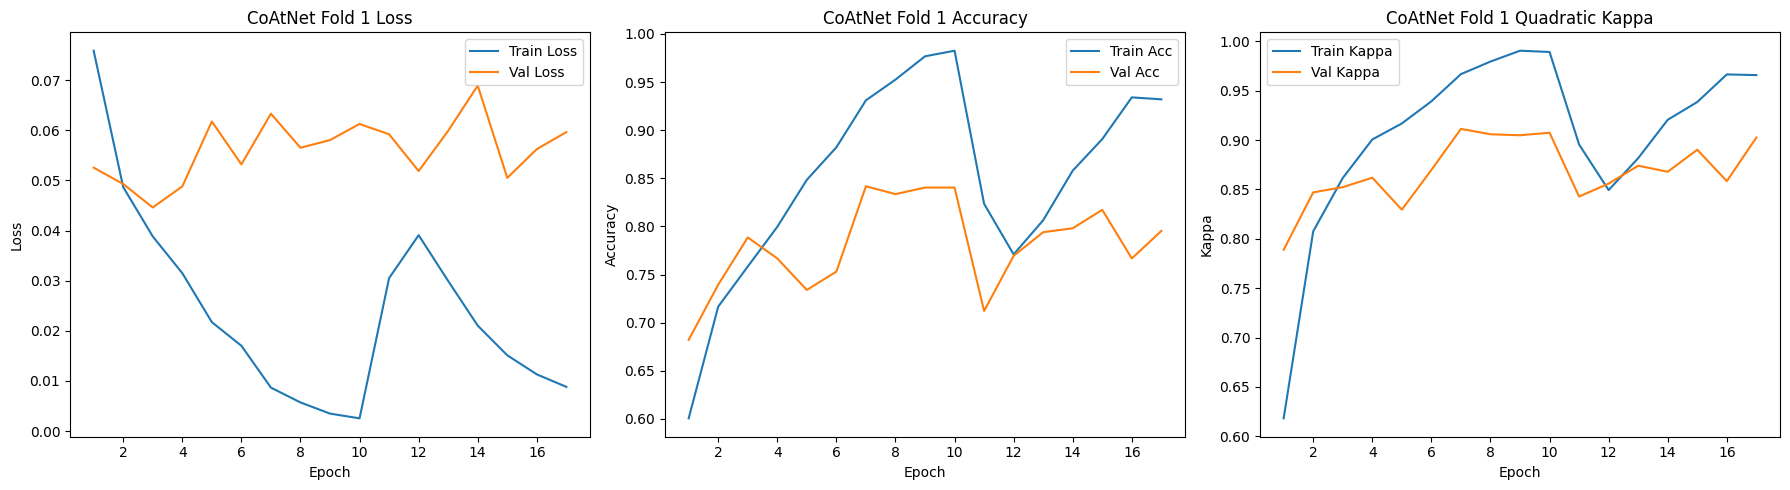


🔁 Fold 2/5


/tmp/ipykernel_36/217215347.py:7: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()
[CoAtNet_Fold2 Epoch 1/25] Training: 100%|██████████| 92/92 [00:25<00:00,  3.59it/s]


[CoAtNet_Fold2 Epoch 1]: Train Loss=0.0703, Acc=0.6115, Kappa=0.6761 | Val Loss=0.0524, Acc=0.7203, Kappa=0.8290 | LR=0.000293
✅ Best CoAtNet_Fold2 model saved.


[CoAtNet_Fold2 Epoch 2/25] Training: 100%|██████████| 92/92 [00:25<00:00,  3.58it/s]


[CoAtNet_Fold2 Epoch 2]: Train Loss=0.0492, Acc=0.7231, Kappa=0.8315 | Val Loss=0.0451, Acc=0.7531, Kappa=0.8352 | LR=0.000271
✅ Best CoAtNet_Fold2 model saved.


...

[CoAtNet_Fold2 Epoch 23]: Train Loss=0.0015, Acc=0.9891, Kappa=0.9938 | Val Loss=0.0837, Acc=0.8281, Kappa=0.8983 | LR=0.000083
✅ Best CoAtNet_Fold2 model saved.


[CoAtNet_Fold2 Epoch 24/25] Training: 100%|██████████| 92/92 [00:25<00:00,  3.66it/s]


[CoAtNet_Fold2 Epoch 24]: Train Loss=0.0014, Acc=0.9891, Kappa=0.9939 | Val Loss=0.0961, Acc=0.8172, Kappa=0.8944 | LR=0.000063


[CoAtNet_Fold2 Epoch 25/25] Training: 100%|██████████| 92/92 [00:25<00:00,  3.65it/s]


[CoAtNet_Fold2 Epoch 25]: Train Loss=0.0014, Acc=0.9870, Kappa=0.9935 | Val Loss=0.0890, Acc=0.8117, Kappa=0.8902 | LR=0.000045


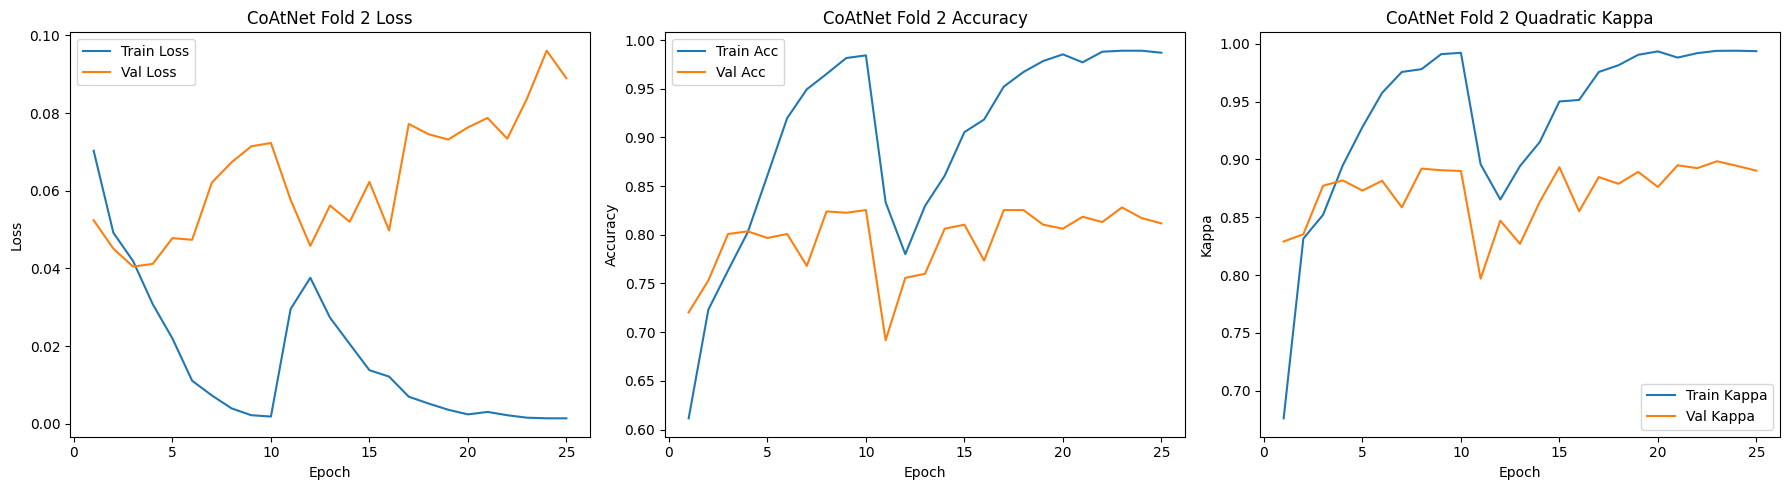


🔁 Fold 3/5


/tmp/ipykernel_36/217215347.py:7: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()
[CoAtNet_Fold3 Epoch 1/25] Training: 100%|██████████| 92/92 [00:25<00:00,  3.57it/s]


[CoAtNet_Fold3 Epoch 1]: Train Loss=0.0702, Acc=0.6249, Kappa=0.7109 | Val Loss=0.0893, Acc=0.6489, Kappa=0.7534 | LR=0.000293
✅ Best CoAtNet_Fold3 model saved.


[CoAtNet_Fold3 Epoch 2/25] Training: 100%|██████████| 92/92 [00:25<00:00,  3.57it/s]


[CoAtNet_Fold3 Epoch 2]: Train Loss=0.0446, Acc=0.7403, Kappa=0.8380 | Val Loss=0.0472, Acc=0.7555, Kappa=0.8340 | LR=0.000271
✅ Best CoAtNet_Fold3 model saved.


...

[CoAtNet_Fold3 Epoch 18]: Train Loss=0.0062, Acc=0.9590, Kappa=0.9794 | Val Loss=0.0673, Acc=0.8320, Kappa=0.8914 | LR=0.000197


[CoAtNet_Fold3 Epoch 19/25] Training: 100%|██████████| 92/92 [00:25<00:00,  3.58it/s]


[CoAtNet_Fold3 Epoch 19]: Train Loss=0.0060, Acc=0.9567, Kappa=0.9759 | Val Loss=0.0598, Acc=0.8347, Kappa=0.8927 | LR=0.000174


[CoAtNet_Fold3 Epoch 20/25] Training: 100%|██████████| 92/92 [00:25<00:00,  3.59it/s]


[CoAtNet_Fold3 Epoch 20]: Train Loss=0.0043, Acc=0.9700, Kappa=0.9842 | Val Loss=0.0585, Acc=0.8224, Kappa=0.8864 | LR=0.000150
⛔ Early stopping for CoAtNet_Fold3 after 10 epochs.


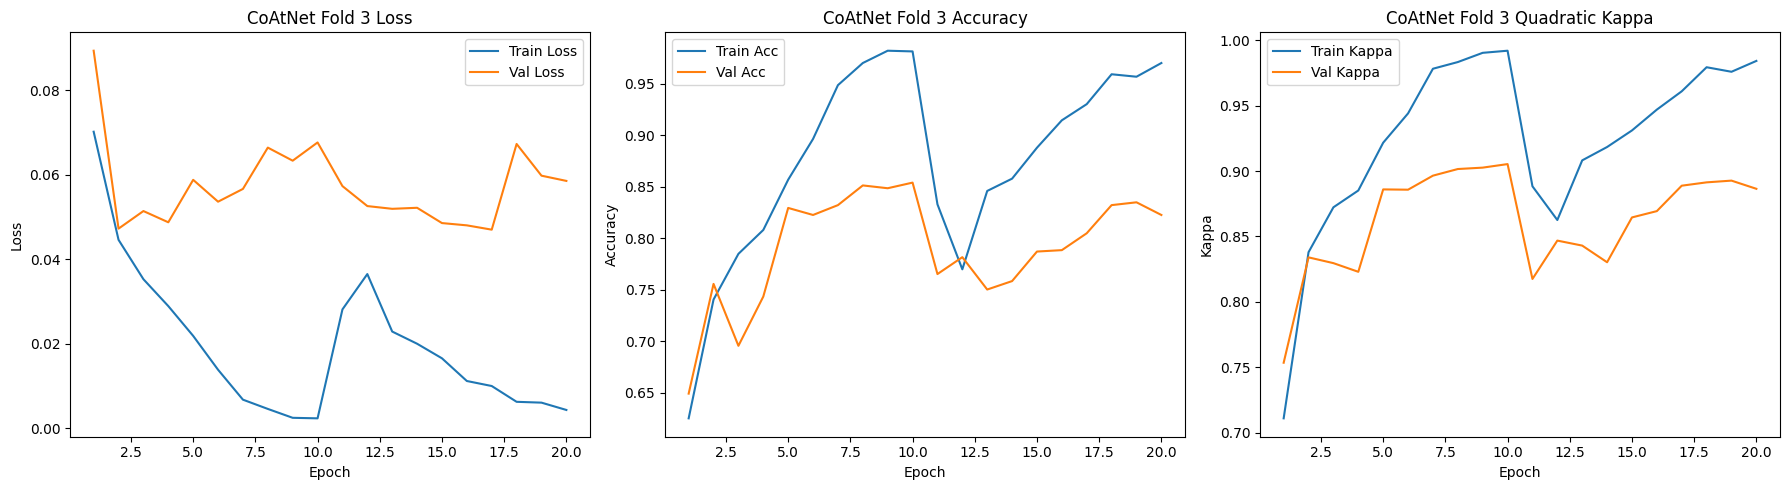


🔁 Fold 4/5


/tmp/ipykernel_36/217215347.py:7: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()
[CoAtNet_Fold4 Epoch 1/25] Training: 100%|██████████| 92/92 [00:25<00:00,  3.58it/s]


[CoAtNet_Fold4 Epoch 1]: Train Loss=0.0804, Acc=0.5860, Kappa=0.6198 | Val Loss=0.0629, Acc=0.6899, Kappa=0.7242 | LR=0.000293
✅ Best CoAtNet_Fold4 model saved.


[CoAtNet_Fold4 Epoch 2/25] Training: 100%|██████████| 92/92 [00:25<00:00,  3.58it/s]


[CoAtNet_Fold4 Epoch 2]: Train Loss=0.0520, Acc=0.7235, Kappa=0.8097 | Val Loss=0.0464, Acc=0.6762, Kappa=0.7854 | LR=0.000271
✅ Best CoAtNet_Fold4 model saved.


...

[CoAtNet_Fold4 Epoch 18]: Train Loss=0.0068, Acc=0.9464, Kappa=0.9685 | Val Loss=0.0657, Acc=0.8265, Kappa=0.8978 | LR=0.000197


[CoAtNet_Fold4 Epoch 19/25] Training: 100%|██████████| 92/92 [00:25<00:00,  3.59it/s]


[CoAtNet_Fold4 Epoch 19]: Train Loss=0.0061, Acc=0.9621, Kappa=0.9795 | Val Loss=0.0522, Acc=0.8333, Kappa=0.9051 | LR=0.000174


[CoAtNet_Fold4 Epoch 20/25] Training: 100%|██████████| 92/92 [00:25<00:00,  3.62it/s]


[CoAtNet_Fold4 Epoch 20]: Train Loss=0.0040, Acc=0.9724, Kappa=0.9877 | Val Loss=0.0630, Acc=0.8388, Kappa=0.9051 | LR=0.000150
⛔ Early stopping for CoAtNet_Fold4 after 10 epochs.


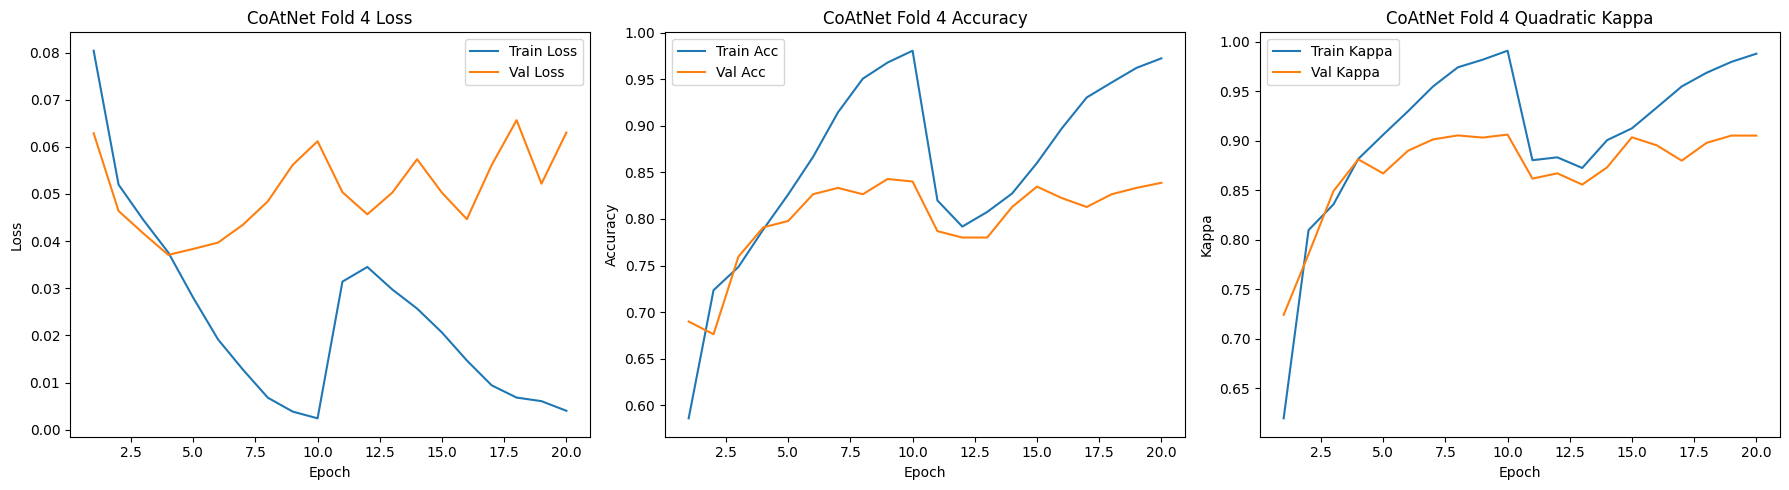


🔁 Fold 5/5


/tmp/ipykernel_36/217215347.py:7: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()
[CoAtNet_Fold5 Epoch 1/25] Training: 100%|██████████| 92/92 [00:25<00:00,  3.57it/s]


[CoAtNet_Fold5 Epoch 1]: Train Loss=0.0726, Acc=0.6246, Kappa=0.6949 | Val Loss=0.0589, Acc=0.6858, Kappa=0.8019 | LR=0.000293
✅ Best CoAtNet_Fold5 model saved.


[CoAtNet_Fold5 Epoch 2/25] Training: 100%|██████████| 92/92 [00:25<00:00,  3.57it/s]


[CoAtNet_Fold5 Epoch 2]: Train Loss=0.0478, Acc=0.7232, Kappa=0.8275 | Val Loss=0.0555, Acc=0.6831, Kappa=0.7661 | LR=0.000271


...

[CoAtNet_Fold5 Epoch 23]: Train Loss=0.0015, Acc=0.9911, Kappa=0.9956 | Val Loss=0.0778, Acc=0.8224, Kappa=0.8958 | LR=0.000083


[CoAtNet_Fold5 Epoch 24/25] Training: 100%|██████████| 92/92 [00:25<00:00,  3.61it/s]


[CoAtNet_Fold5 Epoch 24]: Train Loss=0.0016, Acc=0.9881, Kappa=0.9944 | Val Loss=0.0733, Acc=0.8197, Kappa=0.8960 | LR=0.000063


[CoAtNet_Fold5 Epoch 25/25] Training: 100%|██████████| 92/92 [00:25<00:00,  3.60it/s]


[CoAtNet_Fold5 Epoch 25]: Train Loss=0.0013, Acc=0.9915, Kappa=0.9954 | Val Loss=0.0800, Acc=0.8374, Kappa=0.9010 | LR=0.000045


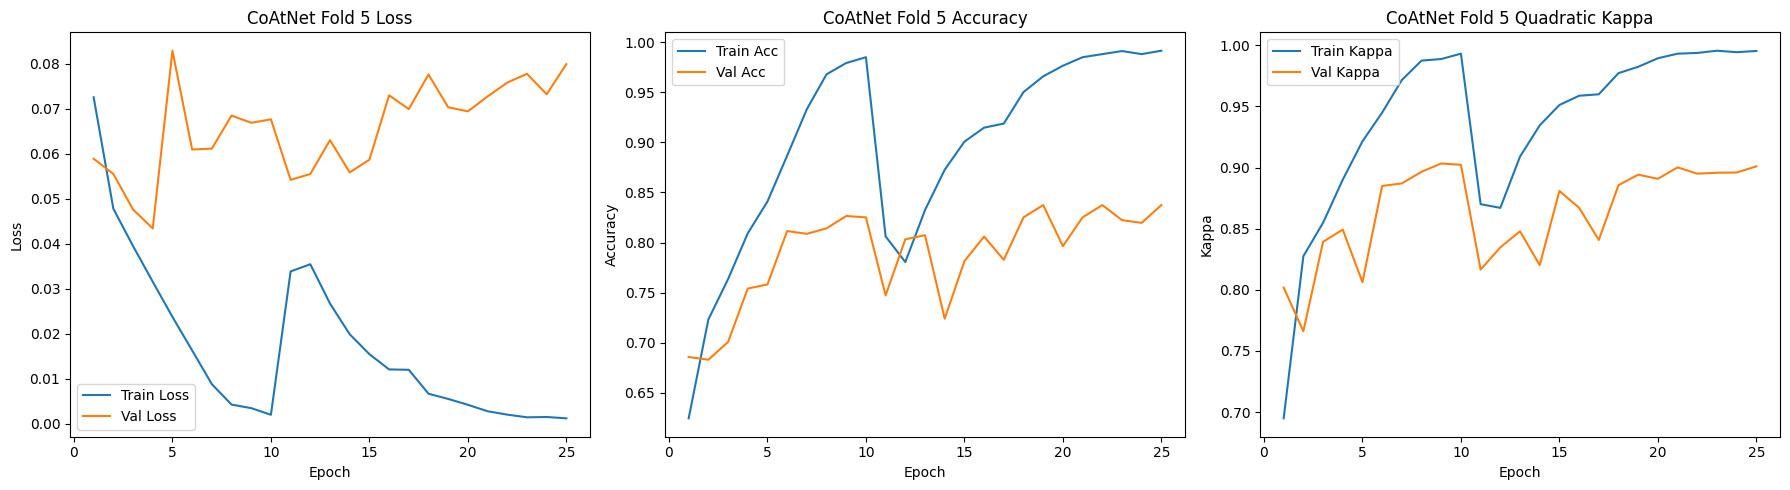

In [205]:
#Cell 8
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
fold_results = []

for fold, (train_idx, val_idx) in enumerate(skf.split(df, df['diagnosis'])):
    print(f"\n🔁 Fold {fold+1}/5")

    train_df = df.iloc[train_idx].reset_index(drop=True)
    val_df = df.iloc[val_idx].reset_index(drop=True)

    train_dataset = DRDataset(train_df, image_dir=image_dir, transform=train_transform)
    val_dataset = DRDataset(val_df, image_dir=image_dir, transform=val_transform)

    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

    model = CoAtNetModel(num_classes=NUM_CLASSES).to(device)

    # Class weights for focal loss
    class_counts = train_df['diagnosis'].value_counts().sort_index()
    alpha_loss = 1.0 / class_counts.values
    alpha_loss = torch.tensor(alpha_loss, dtype=torch.float).to(device)
    alpha_loss = alpha_loss / alpha_loss.sum()

    criterion = FocalLoss(alpha=alpha_loss, gamma=FOCAL_LOSS_GAMMA).to(device)
    optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    scheduler = CosineAnnealingWarmRestarts(optimizer, T_0=10, T_mult=2, eta_min=1e-6)

    model_path, best_kappa, best_acc, history = train_model(
        model_name=f"CoAtNet_Fold{fold+1}",
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        criterion=criterion,
        optimizer=optimizer,
        scheduler=scheduler,
        device=device,
        epochs=EPOCHS,
        patience=EARLY_STOPPING_PATIENCE,
        min_delta_kappa=MIN_DELTA_KAPPA
    )

    fold_results.append({
        'fold': fold+1,
        'val_kappa': best_kappa,
        'val_acc': best_acc,
        'model_path': model_path
    })
    
    fold_models.append(model)
    fold_val_dfs.append(val_df)
    plot_training_curves(history, model_name=f"CoAtNet Fold {fold+1}")

In [206]:
#Cell 9
print("\n📊 Final Cross-Validation Results:")
for res in fold_results:
    print(f"Fold {res['fold']}: Val Kappa = {res['val_kappa']:.4f}, Val Acc = {res['val_acc']:.4f}")

avg_kappa = sum(res['val_kappa'] for res in fold_results) / 5
avg_acc = sum(res['val_acc'] for res in fold_results) / 5

print(f"\n✅ Avg Val Kappa: {avg_kappa:.4f}")
print(f"✅ Avg Val Accuracy: {avg_acc:.4f}")


📊 Final Cross-Validation Results:
Fold 1: Val Kappa = 0.9113, Val Acc = 0.8417
Fold 2: Val Kappa = 0.8983, Val Acc = 0.8281
Fold 3: Val Kappa = 0.9053, Val Acc = 0.8538
Fold 4: Val Kappa = 0.9061, Val Acc = 0.8429
Fold 5: Val Kappa = 0.9033, Val Acc = 0.8374

✅ Avg Val Kappa: 0.9049
✅ Avg Val Accuracy: 0.8408


In [210]:
from sklearn.metrics import classification_report, roc_auc_score, roc_curve, auc, ConfusionMatrixDisplay, confusion_matrix
import matplotlib.pyplot as plt
import torch.nn.functional as F

NUM_CLASSES = 5
class_names = ['No_DR', 'Mild', 'Moderate', 'Severe', 'Proliferate_DR']

In [211]:
from sklearn.model_selection import StratifiedKFold

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
fold_val_loaders = []
fold_models = []

for fold, (train_idx, val_idx) in enumerate(kf.split(df, df['diagnosis'])):
    val_df = df.iloc[val_idx].reset_index(drop=True)

    val_dataset = DRDataset(val_df, image_dir=image_dir, transform=val_transform)
    val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2)
    fold_val_loaders.append(val_loader)

    # Load model
    model = CoAtNetModel(num_classes=NUM_CLASSES).to(device)
    model.load_state_dict(torch.load(f"best_CoAtNet_Fold{fold+1}.pth"))
    model.eval()
    fold_models.append(model)

In [212]:
import numpy as np

def evaluate_fold_model(model, loader, fold_idx):
    all_preds = []
    all_labels = []
    all_probs = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)

            probs = F.softmax(outputs, dim=1).detach().cpu().numpy()
            preds = np.argmax(probs, axis=1)

            all_preds.extend(preds)
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs)

    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)
    all_probs = np.array(all_probs)

    print(f"\n--- Fold {fold_idx+1} Classification Report ---")
    print(classification_report(all_labels, all_preds, target_names=class_names))

    # Confusion Matrix
    cm = confusion_matrix(all_labels, all_preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(cmap='Blues', xticks_rotation=45)
    plt.title(f'Confusion Matrix - Fold {fold_idx+1}')
    plt.show()

    return all_labels, all_preds, all_probs


--- Fold 1 Classification Report ---
                precision    recall  f1-score   support

         No_DR       1.00      0.99      0.99       361
          Mild       0.69      0.62      0.65        74
      Moderate       0.75      0.81      0.78       200
        Severe       0.44      0.59      0.51        39
Proliferate_DR       0.72      0.53      0.61        59

      accuracy                           0.84       733
     macro avg       0.72      0.71      0.71       733
  weighted avg       0.85      0.84      0.84       733



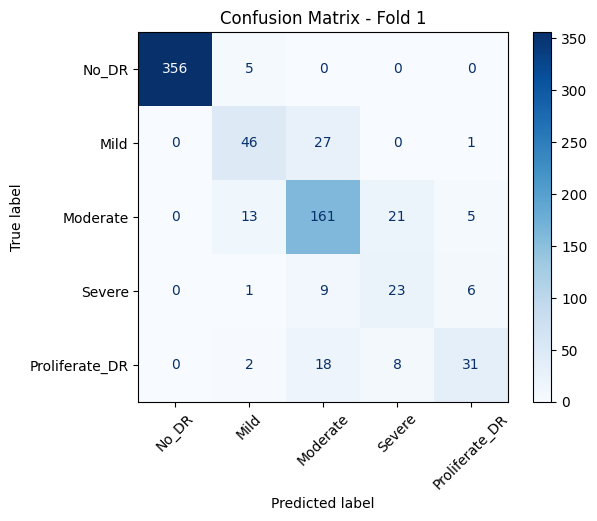


--- Fold 2 Classification Report ---
                precision    recall  f1-score   support

         No_DR       0.98      0.98      0.98       361
          Mild       0.62      0.65      0.63        74
      Moderate       0.76      0.81      0.78       200
        Severe       0.46      0.49      0.48        39
Proliferate_DR       0.60      0.41      0.48        59

      accuracy                           0.83       733
     macro avg       0.68      0.67      0.67       733
  weighted avg       0.82      0.83      0.82       733



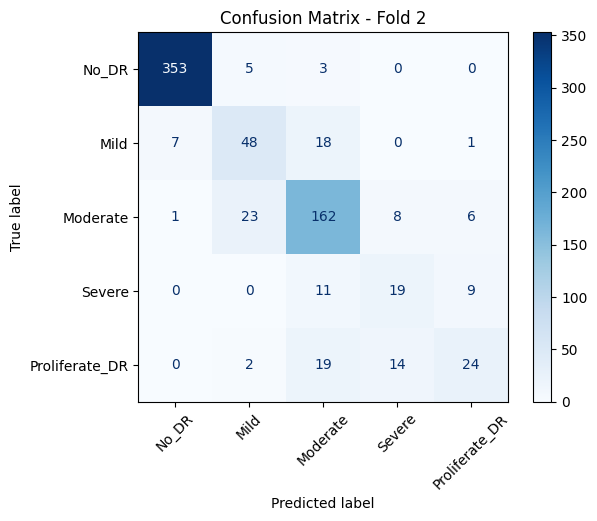


--- Fold 3 Classification Report ---
                precision    recall  f1-score   support

         No_DR       0.99      0.98      0.98       361
          Mild       0.67      0.70      0.68        74
      Moderate       0.78      0.81      0.80       200
        Severe       0.52      0.58      0.55        38
Proliferate_DR       0.76      0.58      0.65        59

      accuracy                           0.85       732
     macro avg       0.74      0.73      0.73       732
  weighted avg       0.86      0.85      0.85       732



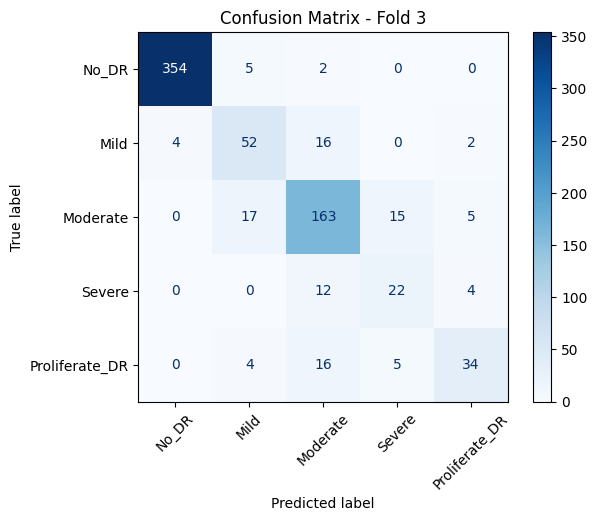


--- Fold 4 Classification Report ---
                precision    recall  f1-score   support

         No_DR       0.98      0.97      0.97       361
          Mild       0.65      0.69      0.67        74
      Moderate       0.79      0.83      0.81       200
        Severe       0.44      0.32      0.37        38
Proliferate_DR       0.61      0.61      0.61        59

      accuracy                           0.84       732
     macro avg       0.69      0.68      0.69       732
  weighted avg       0.84      0.84      0.84       732



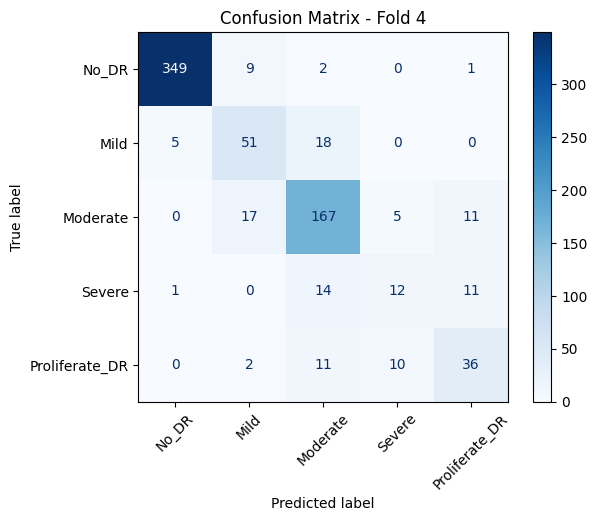


--- Fold 5 Classification Report ---
                precision    recall  f1-score   support

         No_DR       0.98      0.99      0.98       361
          Mild       0.59      0.74      0.66        74
      Moderate       0.80      0.74      0.77       199
        Severe       0.50      0.46      0.48        39
Proliferate_DR       0.67      0.63      0.65        59

      accuracy                           0.84       732
     macro avg       0.71      0.71      0.71       732
  weighted avg       0.84      0.84      0.84       732



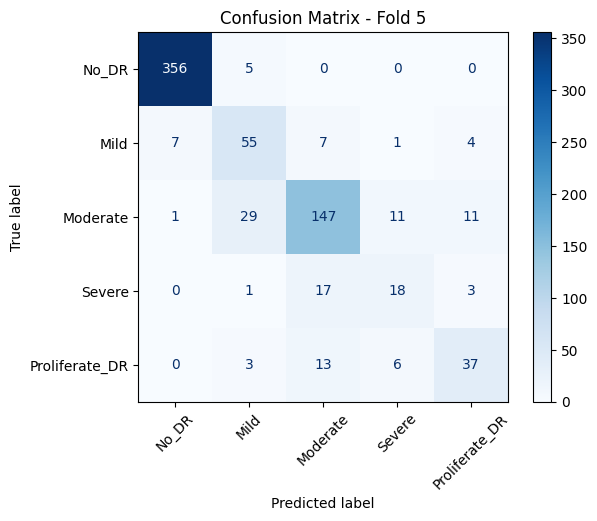

In [213]:
all_labels_all_folds = []
all_preds_all_folds = []
all_probs_all_folds = []

for i in range(5):
    labels, preds, probs = evaluate_fold_model(fold_models[i], fold_val_loaders[i], i)
    all_labels_all_folds.extend(labels)
    all_preds_all_folds.extend(preds)
    all_probs_all_folds.extend(probs)

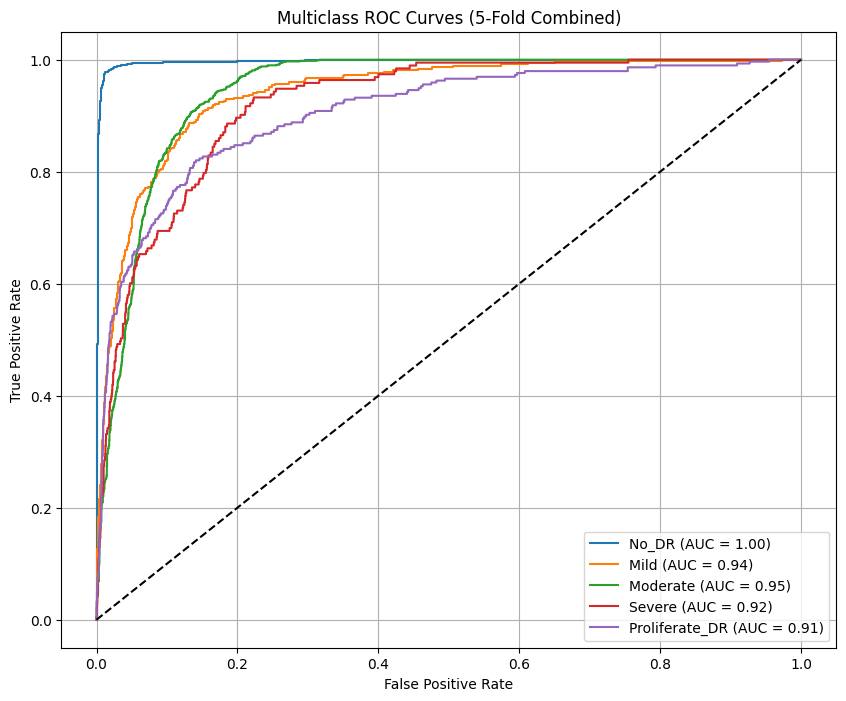

In [214]:
from sklearn.preprocessing import label_binarize

y_true_bin = label_binarize(all_labels_all_folds, classes=range(NUM_CLASSES))
y_score = np.array(all_probs_all_folds)

fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(NUM_CLASSES):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot ROC curves
plt.figure(figsize=(10, 8))
for i in range(NUM_CLASSES):
    plt.plot(fpr[i], tpr[i], label=f"{class_names[i]} (AUC = {roc_auc[i]:.2f})")

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multiclass ROC Curves (5-Fold Combined)')
plt.legend()
plt.grid()
plt.show()

In [215]:
from sklearn.metrics import accuracy_score, cohen_kappa_score

final_acc = accuracy_score(all_labels_all_folds, all_preds_all_folds)
final_kappa = cohen_kappa_score(all_labels_all_folds, all_preds_all_folds, weights='quadratic')

print(f"✅ Final Overall Accuracy: {final_acc:.4f}")
print(f"✅ Final Overall QWK Score: {final_kappa:.4f}")

✅ Final Overall Accuracy: 0.8400
✅ Final Overall QWK Score: 0.9030


In [216]:
#Cell 10
# Save best model from best fold
best_fold = max(fold_results, key=lambda x: x['val_kappa'])
best_model = fold_models[best_fold['fold'] - 1]
best_val_df = fold_val_dfs[best_fold['fold'] - 1]

print(f"\n🏆 Best Fold: {best_fold['fold']} | Kappa: {best_fold['val_kappa']:.4f}, Acc: {best_fold['val_acc']:.4f}")


🏆 Best Fold: 1 | Kappa: 0.9113, Acc: 0.8417


In [ ]:
##################################################
################################################## 
######### GradCAM Visualisation ##################
##################################################
##################################################

In [220]:
!pip install git+https://github.com/jacobgil/pytorch-grad-cam.git

  Cloning https://github.com/jacobgil/pytorch-grad-cam.git to /tmp/pip-req-build-t8tbnovb
  Running command git clone --filter=blob:none --quiet https://github.com/jacobgil/pytorch-grad-cam.git /tmp/pip-req-build-t8tbnovb
  Resolved https://github.com/jacobgil/pytorch-grad-cam.git to commit 781dbc0d16ffa95b6d18b96b7b829840a82d93d1
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.7 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 84.3 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 61.9 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 48.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.5 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.2 MB/s eta 0:00:00:00:0100:01

In [221]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image

In [223]:
print(coatnet_model)

CoAtNetModel(
  (model): MaxxVit(
    (stem): Stem(
      (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (norm1): BatchNormAct2d(
        32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
        (drop): Identity()
        (act): SiLU(inplace=True)
      )
      (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    )
    (stages): Sequential(
      (0): MaxxVitStage(
        (blocks): Sequential(
          (0): MbConvBlock(
            (shortcut): Downsample2d(
              (pool): AvgPool2d(kernel_size=2, stride=2, padding=0)
              (expand): Conv2d(64, 96, kernel_size=(1, 1), stride=(1, 1), bias=False)
            )
            (pre_norm): BatchNormAct2d(
              64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
              (drop): Identity()
              (act): SiLU(inplace=True)
            )
            (down): Identity()
            (conv1_1x1): Con